In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import logging
import os
import sys
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd


# Add the parent directory (which contains the fmcg package) to Python path, thereby enabling `import fmcg`. Remove this line if this script is located in the same folder as the 'fmcg' folder.
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
import fmcg
import fmcg.workspace_config
from fmcg.configs.measurement_config_2024_07_05 import MeasurementConfig, SystemConfig, axis_mask

import sys
sys.path.append('/jonas/fMCG')

import importlib
if 'ica_component_labeler' in sys.modules:
    importlib.reload(sys.modules['ica_component_labeler'])
from ica_component_labeler import ICAComponentLabeler

logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

In [3]:
params = dict(
    patient="P070",
    series="S01",
    sig_group_names="R001",
    noise_group_names="R004",
    bandpass_low=1,
    bandpass_high=40,
    whitening="PCA",
    SystemConfig=SystemConfig,
    MeasurementConfig=MeasurementConfig,
    ica_components=10, 
    sampfrom=0,
    sampto=None,
    downsample_factor=2,
)


from fmcg.pipeline.pipeline import Pipeline
measurements_config = Pipeline().load_measurements_from_labels(
    labels_path=fmcg.workspace_config.FMCG_LABELS_PATH,
    measurement_config_date="D2024-07-05"
)

Using empty recordings from patient P054 S11 for P054 S00.
Using empty recordings from patient P074 S01 for P078 S01.
Using empty recordings from patient P092 S02 for P094 S01.
Using empty recordings from patient P092 S02 for P095 S01.
Using empty recordings from patient P087 S01 for P100 S01.
Using empty recordings from patient P092 S02 for P103 S01.
Using empty recordings from patient P092 S02 for P103 S02.
Using empty recordings from patient P096 S02 for P107 S01.
Using empty recordings from patient P096 S02 for P025 S02.


## Data Loading and Preprocessing

In [ ]:
# healthy_subset = pd.read_csv("/jonas/fMCG/df_annette_filtered.csv")
# healthy_subset = healthy_subset.rename(columns={"signal_group": "sig_group_names"})[["patient", "series", "sig_group_names"]]


In [67]:
healthy_subset = pd.read_csv("/jonas/fMCG/need_to_annotate_ica.csv")
healthy_subset = healthy_subset.rename(columns={"signal_group": "sig_group_names"})[["patient", "series", "sig_group_names"]]


In [70]:
to_process_path = "/jonas/fMCG/2025-09-03_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentV2_fixcopy_outlierV3_500it_1-40hz_newcorr50_win5000_5e-1.csv"
to_process = pd.read_csv(to_process_path)
to_process.rename(columns={"signal_group": "sig_group_names"}, inplace=True)
to_process = to_process.merge(healthy_subset, on=["patient", "series", "sig_group_names"], how="inner")

# join both dataframes to only process the intersection
measurements = to_process.merge(measurements_config, on=["patient", "series"], suffixes=('', 'x'))


print(f"Selected {len(measurements)} measurements to process.")

Selected 9 measurements to process.


In [32]:
to_process_path = "/jonas/fMCG/2025-09-03_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentV2_fixcopy_outlierV3_500it_1-40hz_newcorr50_win5000_5e-1_high_balance_records2.csv"
to_process = pd.read_csv(to_process_path)
to_process = to_process.merge(healthy_subset, on=["patient", "series", "sig_group_names"], how="inner")

# join both dataframes to only process the intersection
measurements = to_process.merge(measurements_config, on=["patient", "series"], suffixes=('', 'x'))

# Duplicate each row and add sampfrom/sampto columns
measurements_expanded = []

for _, row in measurements.iterrows():
    # First row: 0 to mid_point
    row1 = row.copy()
    row1['sampfrom'] = 0
    row1['sampto'] = row['mid_point']
    measurements_expanded.append(row1)
    
    # Second row: mid_point to None
    row2 = row.copy()
    row2['sampfrom'] = row['mid_point']
    row2['sampto'] = None
    measurements_expanded.append(row2)

measurements = pd.DataFrame(measurements_expanded).reset_index(drop=True)
print(f"Selected {len(measurements)} measurements to process.")

Selected 2 measurements to process.


In [69]:
import glob
import os

def get_ica_records_from_path(path):
    ica_files = glob.glob(os.path.join(path, "ica_data_*.npz"))
    ica_records = set()
    for file in ica_files:
        filename = os.path.basename(file)
        parts = filename.split('_')
        if len(parts) >= 8:
            patient = parts[4]
            series = parts[5]
            sig_group = parts[6]
            ica_records.add((patient, series, sig_group))
    return ica_records

set_annette = get_ica_records_from_path("/jonas/fMCG/ica_annotation_annette10")
set_jonas = get_ica_records_from_path("/jonas/fMCG/ica_annotation_jonas10")
len(set_annette), len(set_jonas)

missing_records = set_annette - set_jonas

print(f"\nMissing {len(missing_records)} records in ICA annotations:")
missing_with_indices = []
for patient, series, sig_group in sorted(missing_records):
    # Find indices for this missing record
    indices = [idx for idx, (p, s, sg) in measurements_with_indices if (p, s, sg) == (patient, series, sig_group)]
    missing_with_indices.append((min(indices), patient, series, sig_group, indices))

missing_with_indices.sort()  # Sort by smallest index (first element of tuple)

print(f"\nMissing {len(missing_records)} records in ICA annotations (sorted by smallest index):")
for min_idx, patient, series, sig_group, indices in missing_with_indices:
    print(f"  {patient} {series} {sig_group} (indices: {indices})")

# Optional: Show which ICA files exist but are not in measurements
extra_records = ica_records - measurements_records
if extra_records:
    print(f"\nExtra {len(extra_records)} records in ICA annotations (not in measurements):")
    for patient, series, sig_group in sorted(extra_records):
        print(f"  {patient} {series} {sig_group}")


Missing 0 records in ICA annotations:

Missing 0 records in ICA annotations (sorted by smallest index):


In [81]:
%matplotlib widget
#%matplotlib inline
plt.close('all')

m = measurements.iloc[9]#[19]#[66]

print(m.patient, m.series, m.sig_group_names, m.noise_group_names, m.sampfrom, m.sampto)
params.update({
    'patient': m.patient,
    'series': m.series,
    'sig_group_names': m.sig_group_names,
    'noise_group_names': m.noise_group_names,
    'sampfrom': int(m.sampfrom),
    'sampto': int(m.sampto) if not pd.isna(m.sampto) else None
})

labeler = ICAComponentLabeler(
    params,
    n_components=params['ica_components'],
    xlim=(50,55),
    save_suffix=f"{params['patient']}_{params['series']}_{params['sig_group_names']}_ICA{params['ica_components']}_{params['whitening']}whitening_{params['bandpass_low']}-{params['bandpass_high']}Hz_{params['sampfrom']}s-{params['sampto']}s",
    fig_size=(12.0, 2.0),
    base_path="/jonas/fMCG/ica_annotation_jonas10_full",
    hr_tolerance=3.0,  # BPM tolerance for HR similarity highlighting
    correlation_threshold=0.35  # Threshold for correlation highlighting
)
labeler.show()

IndexError: single positional indexer is out-of-bounds

## Independent Component Subtraction (ICS)

In [ ]:
%matplotlib inline

from copy import deepcopy
import glob
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
from tqdm import tqdm
plt.close('all')


values = []
files = sorted(glob.glob('/jonas/fMCG/ica_annotation_annette10/*.npz'))
for file in tqdm(files, desc="Processing files", total=len(files)):
    patient, series, record = file.split('_')[-7:-4]
    sampfrom, sampto = file.split('_')[-1].replace('.npz','').split('-')
    sampfrom, sampto = int(sampfrom[:-1]), int(sampto[:-1]) if sampto != 'Nones' else np.nan

    data = ICAComponentLabeler.load_exported_data(file)
    compF = np.where(data['component_labels'] == "Fetal")[0]
    maternals = np.where(data['component_labels'] == "Maternal")[0]
    sources = data["sources"]
    ica_mixing_ = data["mixing_matrix"]
    fs = data["fs"]
    bp_data = data["bp_data"]
    ica = data["ica"]

    if len(compF) == 0 or len(maternals) == 0:
        print(f"Skipping {file} due to missing fetal (N={len(compF)}) or maternal components (N={len(maternals)}).")
        continue

    heartRate, peaks = fmcg.ics.plotHR(sources, compF, fs=fs, plot=False)
    ica.mixing_ = ica_mixing_.copy()
    ica.mixing_[:, compF] = 0
    maternal_sources = deepcopy(sources)
    maternal_sources[:, compF] = 0

    maternal_corrected = fmcg.ics.upDownSample(
        maternal_sources, maternals, downsample_factor_qrs=5, downsample_factor_other=20
    )

    maternal_meas = ica.inverse_transform(maternal_sources, True)
    remaining_fetal = bp_data - maternal_meas

    range_segments = fmcg.ics.identify_hr_range_segments(
        heartRate,
        min_hr=np.median(heartRate) - 3,
        max_hr=np.median(heartRate) + 3,
        plot=False,
        min_segment_length=4,
        plt_save=False,
    )

    # average the segments from the remaining field measurements after maternal cancelation
    avg_waveform, std_waveform, num_beats = fmcg.ics.avg_channels_hr_range(
        remaining_fetal,
        peaks,
        heartRate,
        window_size=int(60/np.median(heartRate)*fs)*3, # show three heartbeats
        denoise=False,
        plot=False,
        min_hr=np.median(heartRate) - 3,
        max_hr=np.median(heartRate) + 3,
        plt_save=False,
        return_num_beats=True
    )

    hr_mean = heartRate.mean()
    rr = 60 / heartRate
    sdnn = rr.std()
    rmssd = np.sqrt(np.mean(np.diff(rr) ** 2))


    # metric
    mean_magnitude = np.array(avg_waveform)
    var_magnitude = np.array(std_waveform) **2

    ####v = (np.sqrt(var_magnitude) / np.max(np.abs(mean_magnitude), axis=0)).mean()
    v = (np.sqrt(var_magnitude.mean(axis=0)) / np.sqrt(np.mean(np.square(mean_magnitude), axis=0))).mean()
    #v = np.sqrt(var_magnitude.mean()) / np.sqrt(np.square(mean_magnitude).mean())

    #v = np.sqrt(var_magnitude.mean()) / np.max(np.abs(mean_magnitude), axis=0).max()
    


    #idx = np.argmax(np.square(mean_magnitude).mean(axis=1), axis=0)
    #v = np.sqrt(var_magnitude[idx]).mean() / np.max(np.abs(mean_magnitude[idx]))


    values.append([patient, series, record, v, hr_mean, sdnn, rmssd, num_beats, sampfrom, sampto])

Processing files:   0%|          | 0/50 [00:00<?, ?it/s]

Processing files: 100%|██████████| 50/50 [01:10<00:00,  1.40s/it]


In [ ]:
#plt.plot(mean_magnitude.T)
plt.plot(np.max(np.abs(mean_magnitude), axis=0), 'k--')
plt.plot(np.abs(mean_magnitude)[np.argmax(np.abs(mean_magnitude).max(axis=1), axis=0)], 'r--')
plt.plot(var_magnitude[np.argmax(np.abs(mean_magnitude).max(axis=1), axis=0)], 'g--')
plt.plot(var_magnitude.T, 'k--', alpha=0.3)


In [ ]:
plt.plot(np.square(mean_magnitude).T)
plt.show()

plt.plot((var_magnitude).T)
plt.show()

plt.plot((var_magnitude/mean_magnitude.max(axis=1, keepdims=True)).T)
plt.show()

In [41]:
def snr(data):
    if 'heartbeats_dict' not in data:
        return np.nan
    if 'fetal' not in data['heartbeats_dict'] or 'M_x' not in data['heartbeats_dict']['fetal']:
        return np.nan
    if data['heartbeats_dict']['fetal']['M_x']['selected_peaks_mask'].sum() < 50:
        return np.nan

    mean_magnitude = np.array([data['heartbeats_dict']['fetal'][ax]['mean_beat'].values for ax in ['M_x', 'M_y', 'M_z']])
    var_magnitude = np.array([data['heartbeats_dict']['fetal'][ax]['std_beat'].values for ax in ['M_x', 'M_y', 'M_z']]) **2
    #v =  np.sqrt(var_magnitude.mean()) / np.linalg.norm(mean_magnitude, axis=0).max()
    #v = np.sqrt(var_magnitude.mean()) / np.sqrt(np.square(mean_magnitude).mean())

    ##v = (np.sqrt(var_magnitude) / np.abs(mean_magnitude)).mean()
    v = np.sqrt(var_magnitude.mean()) / np.max(np.abs(mean_magnitude), axis=0).max()

    # idx = np.argmax(np.square(mean_magnitude).mean(axis=1), axis=0)
    # v = np.sqrt(var_magnitude[idx]).mean() / np.max(np.abs(mean_magnitude[idx]))

    return v

dir = "/jonas/fMCG/output"
# trial = "2025-09-03_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentV2_fixcopy_outlierV3_500it_1-40hz_newcorr50_win5000_5e-1"
# #trial = "2025-07-30_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentLMSv2_fixcopy_v2"
trial = "2025-09-22_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentV2_fixcopy_outlierV3_500it_1-40hz_newcorr50_win5000_5e-1_HOLDOUT_TEMP"
records = sorted(glob.glob(os.path.join(dir, trial, "*/*.pkl")))

values_fw = np.array([snr(np.load(record, allow_pickle=True)) for record in records])

In [ ]:
(np.sqrt(var_magnitude.mean(axis=0)) / np.sqrt(np.mean(np.square(mean_magnitude), axis=0))).mean()

In [ ]:
data = np.load(records[0], allow_pickle=True)
mean_magnitude = np.array([data['heartbeats_dict']['fetal'][ax]['mean_beat'].values for ax in ['M_x', 'M_y', 'M_z']])
var_magnitude = np.array([data['heartbeats_dict']['fetal'][ax]['std_beat'].values for ax in ['M_x', 'M_y', 'M_z']]) **2

plt.plot(mean_magnitude.T)
for i in range(mean_magnitude.shape[0]):
    plt.fill_between(
        np.arange(mean_magnitude.shape[1]),
        mean_magnitude[i] + np.sqrt(var_magnitude[i]),
        mean_magnitude[i] - np.sqrt(var_magnitude[i]),
        color='gray', alpha=0.5
)


# plt.plot((var_magnitude).T)
# plt.show()

# plt.plot((var_magnitude/mean_magnitude.max(axis=1, keepdims=True)).T)
# plt.show()

pos = np.array([data['heartbeats_dict']['fetal'][ax]['mean_position'].values for ax in ['M_x', 'M_y', 'M_z']])
r_sensors = fmcg.data.generate_array_coordinates(grid_shape=(4, 4), grid_spacing=0.04, y=0)
field_var = fmcg.fitting.ForwardModel(r_sensors).forward_linear(pos[:,None,:].T, var_magnitude[:,None,:].T, as_numpy=True)
field_mean = fmcg.fitting.ForwardModel(r_sensors).forward_linear(pos[:,None,:].T, mean_magnitude[:,None,:].T, as_numpy=True)


In [ ]:
field_rec = fmcg.fitting.ForwardModel(r_sensors).forward_linear(data["data_dict"]["fetal"]['position'][:,None,:], data["data_dict"]["fetal"]['dipole_moments'][:,None,:], as_numpy=True)
artifacts = data["data_dict"]["fetal"]['artifacts']
#field_rec[artifacts] = 0
outlier = data["data_dict"]["fetal"]["outlier"]
peaks = data["data_dict"]["fetal"]["peaks"][~outlier]
fs = 500
all_intervals = np.diff(peaks) / fs
heartRate = 60 / all_intervals


range_segments = fmcg.ics.identify_hr_range_segments(
    heartRate,
    min_hr=np.median(heartRate) - 3,
    max_hr=np.median(heartRate) + 3,
    plot=False,
    min_segment_length=4,
    plt_save=False,
)

# average the segments from the remaining field measurements after maternal cancelation
avg_waveform, std_waveform, num_beats = fmcg.ics.avg_channels_hr_range(
    field_rec.reshape(field_rec.shape[0], -1),
    peaks,
    heartRate,
    window_size=int(60/np.median(heartRate)*fs)*3, # show three heartbeats
    denoise=False,
    plot=True,
    min_hr=np.median(heartRate) - 3,
    max_hr=np.median(heartRate) + 3,
    plt_save=False,
    return_num_beats=True
)
avg_waveform.shape, std_waveform.shape, num_beats

# Plots / Eval

In [ ]:
# trial ="/jonas/fMCG/output/2025-09-22_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentV2_fixcopy_outlierV3_500it_1-40hz_newcorr50_win5000_5e-1_HOLDOUT_TEMP/processed_records.csv"
# df_fw = pd.read_csv(trial)
# df_fw['hr_success'] = "success"
# df_fw.to_csv(trial, index=False)

In [44]:
import ast

def get_min_from_list_str(list_str, fs=500):
    if pd.isna(list_str):
        return np.nan
    try:
        # Convert the string representation to a list
        values_list = ast.literal_eval(list_str)
        
        # Filter out inf values
        finite_values = [v for v in values_list if not np.isinf(v)]
        
        # Return the minimum if there are finite values, otherwise NaN
        return np.min(finite_values) / fs if finite_values else np.nan
    except:
        return np.nan

trial = "/jonas/fMCG/2025-09-03_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentV2_fixcopy_outlierV3_500it_1-40hz_newcorr50_win5000_5e-1.csv"
#trial = "/jonas/fMCG/2025-07-30_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentLMSv2_fixcopy_v2.csv"
trial ="/jonas/fMCG/output/2025-09-22_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentV2_fixcopy_outlierV3_500it_1-40hz_newcorr50_win5000_5e-1_HOLDOUT_TEMP/processed_records.csv"
df_fw = pd.read_csv(trial)
df_fw = df_fw[["patient", "series", "signal_group", "sdnn_fetal", "center_hr_fetal", "selected_hr_fetal", "selected_beats_fetal", "gestation", "hr_success", "noise_group", "sampfrom", "sampto"]]
df_fw = df_fw.dropna(subset=['noise_group'])
df_fw.sampfrom = df_fw.sampfrom.astype(int)
df_fw.sampto = df_fw.sampto.apply(lambda x: int(x) if not np.isnan(x) else np.nan)
# # drop row with P096 S01 R001
# df_fw = df_fw[~((df_fw.patient == "P096") & (df_fw.series == "S01") & (df_fw.signal_group == "R001"))]
df_fw['value'] = values_fw
df_fw = df_fw[df_fw.hr_success == "success"]
df_fw['sdnn_fetal'] = df_fw['sdnn_fetal'].apply(get_min_from_list_str)
df_fw['GA'] = df_fw['gestation'].str[1:].astype(float)

df_fw.set_index(['patient', 'series', 'signal_group', "sampfrom", "sampto"], inplace=True)


df = pd.DataFrame(values, columns=['patient', 'series', 'signal_group', 'value', 'selected_hr_fetal', 'sdnn_fetal', 'RMSSD', 'selected_beats_fetal', "sampfrom", "sampto"])
df.set_index(['patient', 'series', 'signal_group', "sampfrom", "sampto"], inplace=True)
df_combined = df.join(df_fw, how='inner', lsuffix='_ics', rsuffix='_fw').reset_index()
df_combined["sdnn_fetal_fw"] *= 1000
df_combined["sdnn_fetal_ics"] *= 1000

df_combined = df_combined[df_combined.sampfrom == 0].dropna(subset=['value_ics', 'value_fw'])
df_combined

,patient,series,signal_group,sampfrom,sampto,value_ics,selected_hr_fetal_ics,sdnn_fetal_ics,RMSSD,selected_beats_fetal_ics,sdnn_fetal_fw,center_hr_fetal,selected_hr_fetal_fw,selected_beats_fetal_fw,gestation,hr_success,noise_group,value_fw,GA
1,P056,S02,R002,0,298.0,1.958676,150.143837,18.979428,0.004501,257,5.5236,150.23,149.05,258.0,G38,success,R004,0.237281,38.0
2,P066,S01,R003,0,148.0,2.294796,122.584339,41.191086,0.062241,158,42.6796,121.12,121.41,133.0,G36,success,Noise,0.123187,36.0
4,P097,S04,R003,0,148.0,5.829550,137.432079,6.899266,0.002520,277,7.4736,137.39,138.12,278.0,G26,success,R004,0.100912,26.0
6,P088,S01,R002,0,298.0,6.199893,138.517798,11.174676,0.003653,376,11.1656,138.52,137.97,383.0,G32,success,R004,0.172944,32.0
9,P054,S09,R002,0,298.0,3.701770,144.377143,17.078112,0.003979,291,15.4060,144.26,143.41,289.0,G29,success,R003,0.094109,29.0
11,P097,S03,R003,0,148.0,5.969084,142.695140,20.669607,0.003317,81,20.9868,142.69,139.19,74.0,G26,success,R004,0.150909,26.0
15,P092,S02,R001,0,148.0,1.681020,127.646984,11.767414,0.004925,171,11.2638,127.72,128.33,191.0,G33,success,R004,0.194655,33.0
17,P054,S11,R001,0,148.0,5.595599,146.795128,9.767453,0.007552,167,8.5092,146.64,147.44,170.0,G31,success,R003,0.205790,31.0
19,P048,S02,R002,0,298.0,3.105551,123.807556,28.947651,0.009035,153,28.9308,123.80,122.36,153.0,G31,success,R004,0.091590,31.0
21,P061,S02,R002,0,298.0,5.497101,144.402513,17.099118,0.005756,336,11.5298,143.63,143.44,333.0,G26,success,R004,0.115438,26.0




Summary statistics of differences (ICS - FW):
Heart Rate differences (BPM):
  Mean: 0.815
  Std:  0.680

Beats count differences:
  Mean: 12.5
  Std:  18.5

SDNN differences (ms):
  Mean: 4.027243
  Std:  7.834856


/tmp/ipykernel_2855292/3209228870.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, zorder=5, widths=0.6, vert=False)


Summary statistics of percentual differences (ICS vs FM):
Heart Rate:
  Mean: 0.59%
  Std:  0.49%
  Median: 0.44%
Beats Count:
  Mean: 5.21%
  Std:  5.47%
  Median: 2.29%
SDNN:
  Mean: 26.76%
  Std:  56.66%
  Median: 5.18%


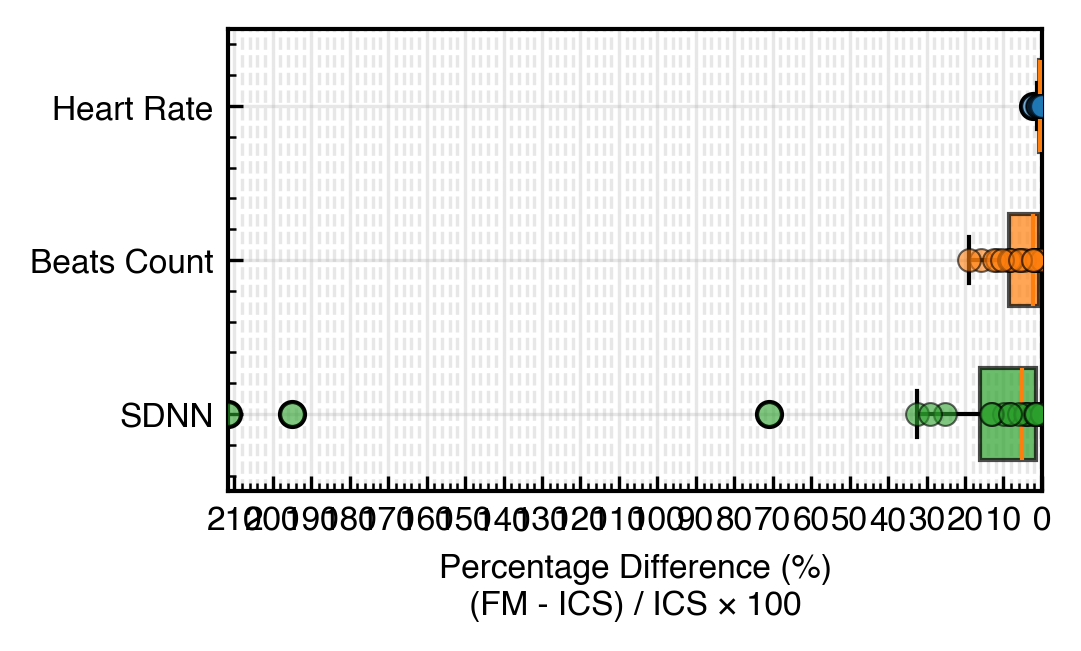

In [50]:
# Calculate differences for each metric
df_combined['hr_diff'] = abs(df_combined['selected_hr_fetal_ics'] - df_combined['selected_hr_fetal_fw'])
df_combined['beats_diff'] = abs(df_combined['selected_beats_fetal_ics'] - df_combined['selected_beats_fetal_fw'])
df_combined['sdnn_diff'] = abs(df_combined['sdnn_fetal_ics'] - df_combined['sdnn_fetal_fw'])

# Display comparison for each row
comparison_cols = ['patient', 'series', 'signal_group', 'sampfrom', 'sampto', 
                   'selected_hr_fetal_ics', 'selected_hr_fetal_fw', 'hr_diff',
                   'selected_beats_fetal_ics', 'selected_beats_fetal_fw', 'beats_diff',
                   'sdnn_fetal_ics', 'sdnn_fetal_fw', 'sdnn_diff']


# Summary statistics of differences
print("\n\nSummary statistics of differences (ICS - FW):")
print("=" * 60)
print(f"Heart Rate differences (BPM):")
print(f"  Mean: {df_combined['hr_diff'].mean():.3f}")
print(f"  Std:  {df_combined['hr_diff'].std():.3f}")

print(f"\nBeats count differences:")
print(f"  Mean: {df_combined['beats_diff'].mean():.1f}")
print(f"  Std:  {df_combined['beats_diff'].std():.1f}")

print(f"\nSDNN differences (ms):")
print(f"  Mean: {df_combined['sdnn_diff'].mean():.6f}")
print(f"  Std:  {df_combined['sdnn_diff'].std():.6f}")

# Create a single box plot showing percentual differences with scatter overlay and different colors
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2), dpi=300)

# Calculate percentual differences
hr_perc = abs((df_combined['selected_hr_fetal_fw'] - df_combined['selected_hr_fetal_ics']) / df_combined['selected_hr_fetal_ics'] * 100).dropna()
beats_perc = abs((df_combined['selected_beats_fetal_fw'] - df_combined['selected_beats_fetal_ics']) / df_combined['selected_beats_fetal_ics'] * 100).dropna()
sdnn_perc = abs((df_combined['sdnn_fetal_fw'] - df_combined['sdnn_fetal_ics']) / df_combined['sdnn_fetal_ics'] * 100).dropna()

# Combine data for plotting
data_to_plot = [hr_perc, beats_perc, sdnn_perc]
labels = ['Heart Rate', 'Beats Count', 'SDNN']
colors = ['tab:blue', 'tab:orange', 'tab:green']

# Create box plot with horizontal orientation and inverted x-axis
bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, zorder=5, widths=0.6, vert=False)

# Color the boxes and add scatter overlay
for i, (patch, color, data) in enumerate(zip(bp['boxes'], colors, data_to_plot)):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    
    # Add scatter overlay
    y_pos = [i + 1] * len(data)
    ax.scatter(data, y_pos, color=color, alpha=0.6, s=30, edgecolor='black', linewidth=0.5, zorder=10)

ax.set_xlabel('Percentage Difference (%)\n(FM - ICS) / ICS × 100')
#ax.set_ylabel('Metrics')
#ax.set_title('Percentual Differences Between ICS and FM')
ax.minorticks_on()
ax.grid(True, alpha=0.3)
ax.grid(which='minor', linestyle='--', alpha=0.3, axis='x')
ax.axvline(x=0, color='k', linestyle='--', alpha=0.7, zorder=0)

# Set finer x-axis ticks
ax.xaxis.set_major_locator(plt.MultipleLocator(10))  # Major ticks every 10 units
ax.xaxis.set_minor_locator(plt.MultipleLocator(2))   # Minor ticks every 2 units
ax.tick_params(axis='x', which='major', labelsize=8)
ax.tick_params(axis='x', which='minor', labelsize=6)

ax.invert_xaxis()  # Invert the x-axis
ax.invert_yaxis()  # Invert the y-axis to have the first metric on top

plt.savefig("ics_vs_fm_percentual_differences_boxplot.pdf", bbox_inches='tight', dpi=300, pad_inches=0.01)
# Print summary statistics
print("Summary statistics of percentual differences (ICS vs FM):")
print("=" * 60)
for label, data in zip(labels, data_to_plot):
    print(f"{label}:")
    print(f"  Mean: {data.mean():.2f}%")
    print(f"  Std:  {data.std():.2f}%")
    print(f"  Median: {data.median():.2f}%")


/tmp/ipykernel_2855292/3517327817.py:24: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2855292/3517327817.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_2855292/3517327817.py:24: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2855292/3517327817.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_2855292/3517327817.py:24: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `den

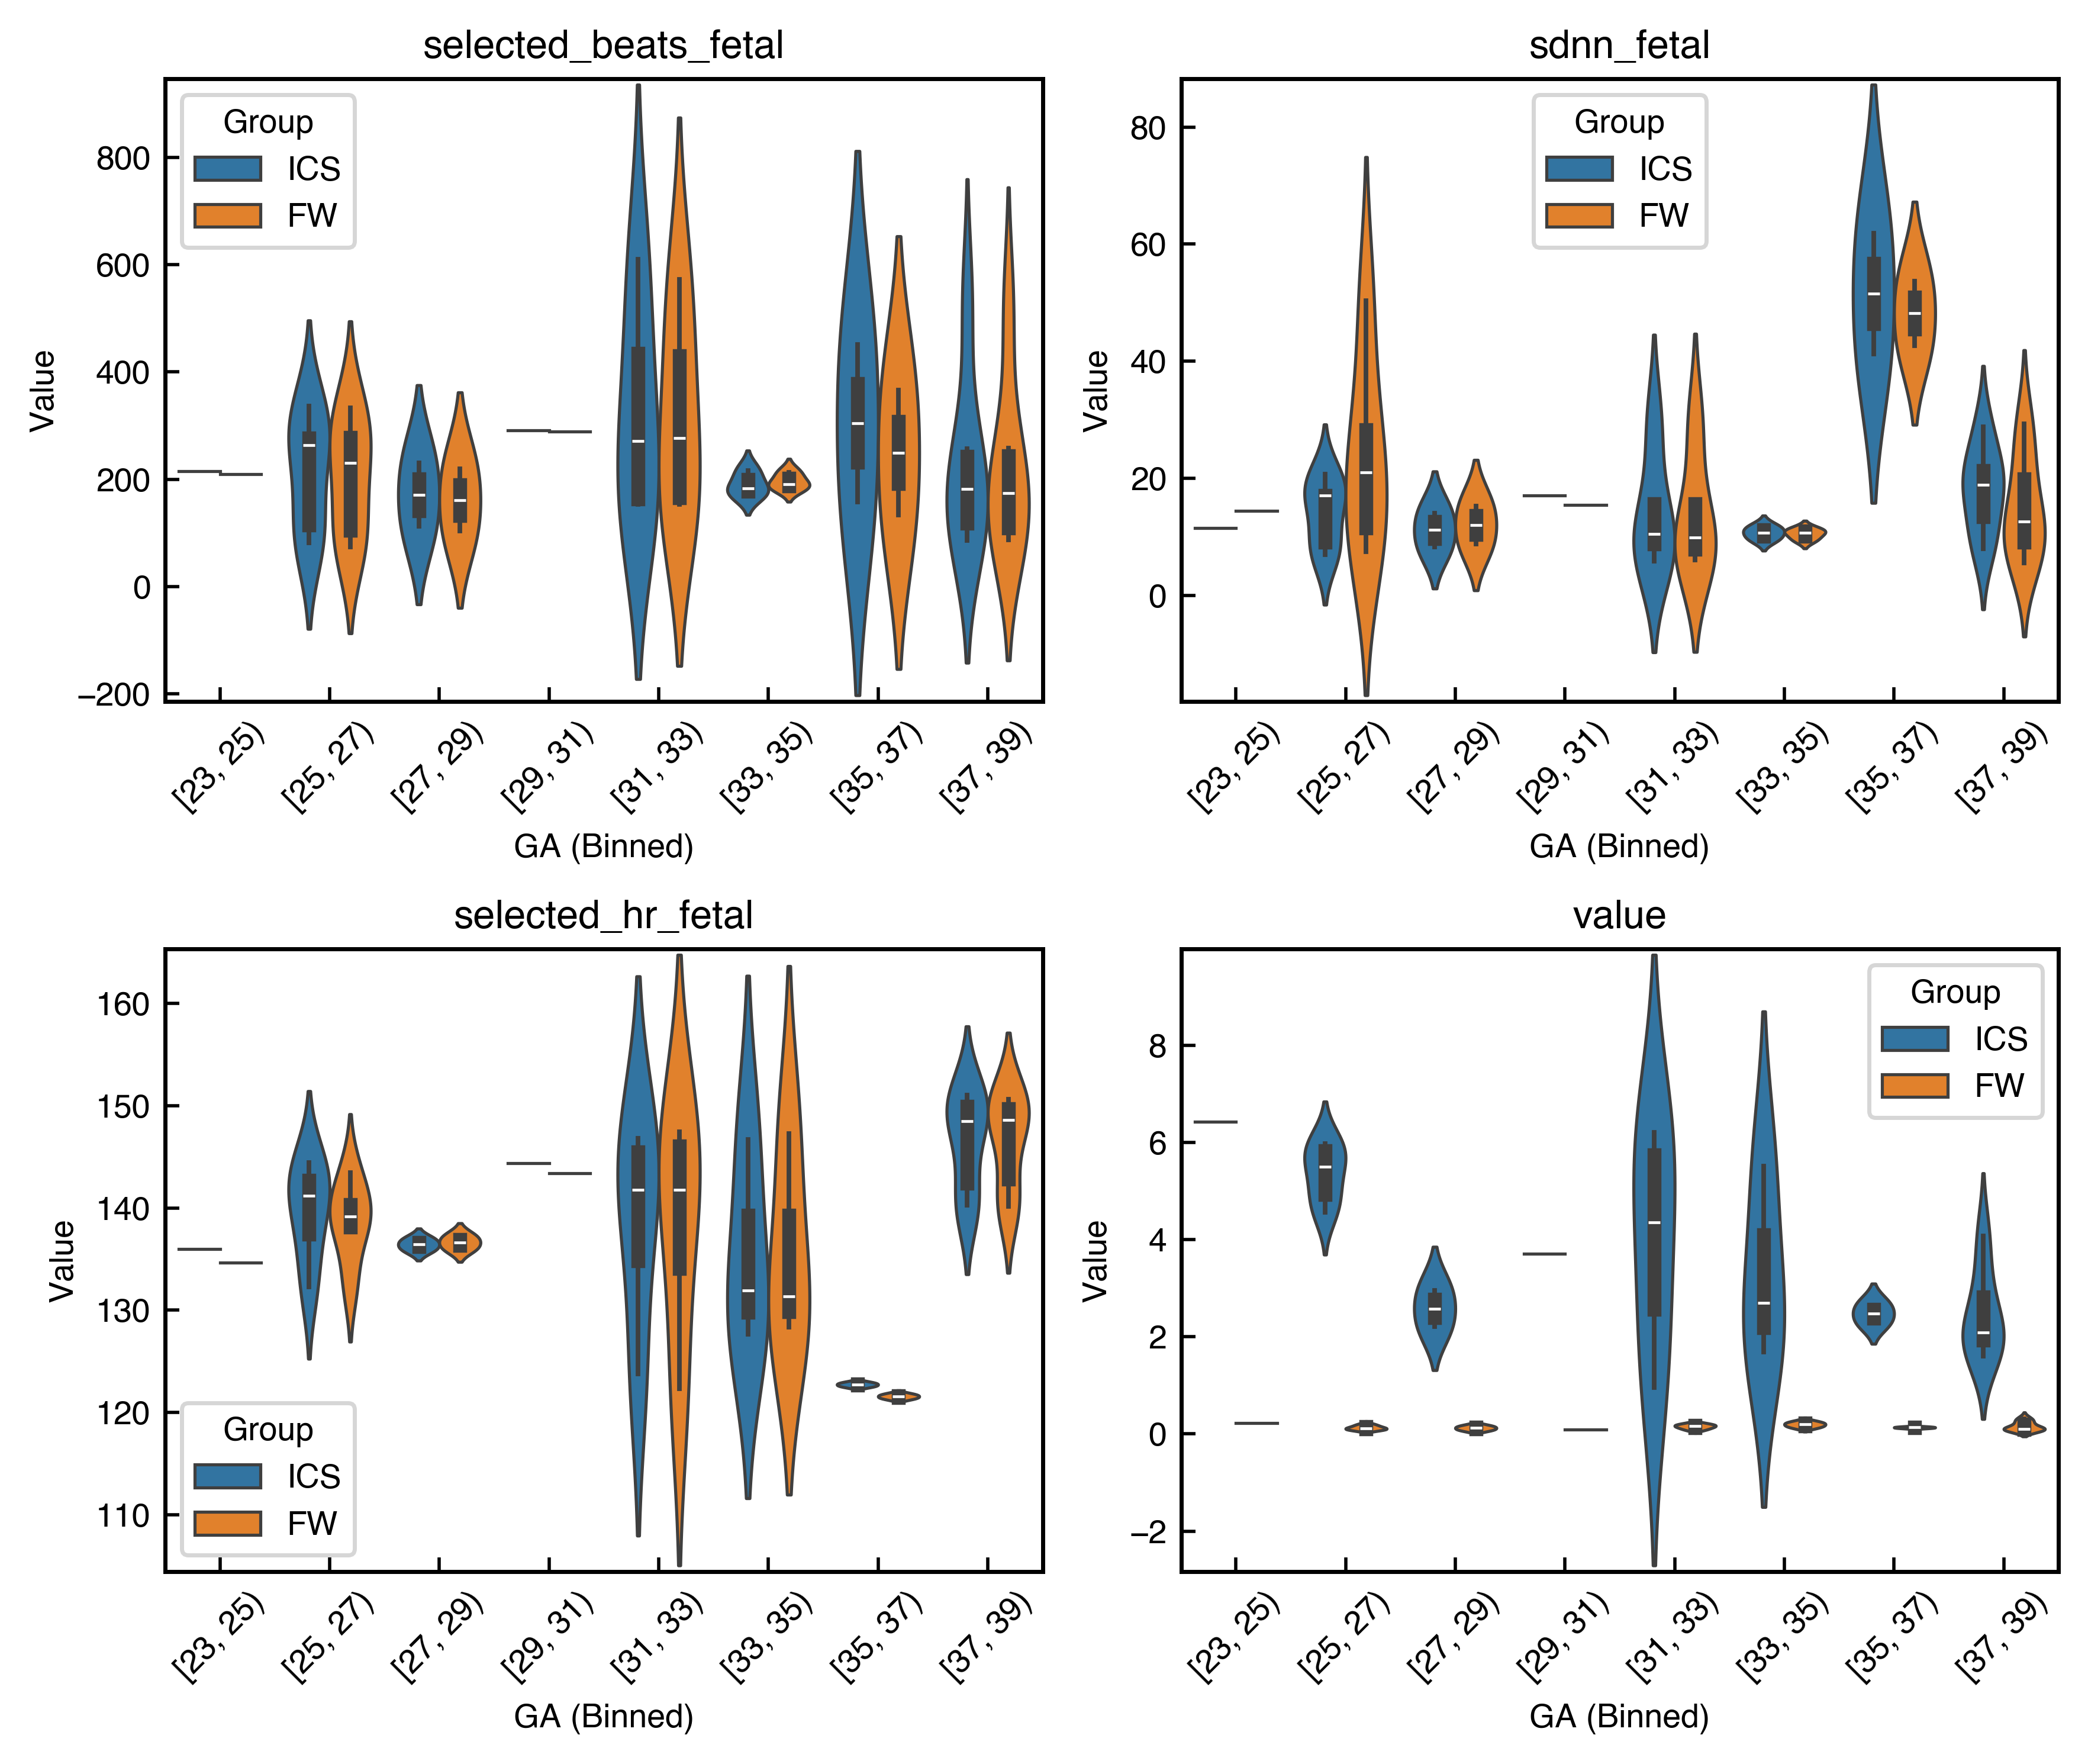

In [48]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

# Combine the two DataFrames (df and df_fw) for comparison

# Melt the DataFrame for visualization
melted_df = df_combined.melt(
	id_vars=['patient', 'series', 'signal_group', 'GA'], 
	value_vars=['selected_beats_fetal_ics', 'selected_beats_fetal_fw', 'sdnn_fetal_ics', 'sdnn_fetal_fw', "selected_hr_fetal_ics", "selected_hr_fetal_fw", "value_ics", "value_fw"], 
	var_name='variable', 
	value_name='value_compare'
)

# Create subplots for each metric
metrics = ['selected_beats_fetal', 'sdnn_fetal', 'selected_hr_fetal', 'value']
fig, axes = plt.subplots(len(metrics)//2, 2, figsize=(7.11, 6))
axes = axes.flatten()
# Update the x-axis to represent 'GA' binned into every second integer and set distinct colors for 'ics' and 'fw' groups
melted_df['GA_binned'] = pd.cut(melted_df['GA'], bins=range(int(melted_df['GA'].min()), int(melted_df['GA'].max()) + 2, 2), right=False)

for i, metric in enumerate(metrics):
    metric_df = melted_df[melted_df['variable'].str.contains(metric)]
    sns.violinplot(
        data=metric_df,
        x='GA_binned',  # Use binned 'GA' for x-axis
        y='value_compare',
        hue=metric_df['variable'].str.contains('_ics').map({True: 'ICS', False: 'FW'}),
        ax=axes[i],
        inner='box',
        width=0.75,
        linewidth=0.75,
        dodge=True,
        scale='width'
    )
    axes[i].set_title(f'{metric}')
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('GA (Binned)')
    axes[i].legend(title='Group')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2855292/2494706898.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['ICA', 'FM'], rotation=45)
/tmp/ipykernel_2855292/2494706898.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['ICA', 'FM'], rotation=45)
/tmp/ipykernel_2855292/2494706898.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['ICA', 'FM'], rotation=45)


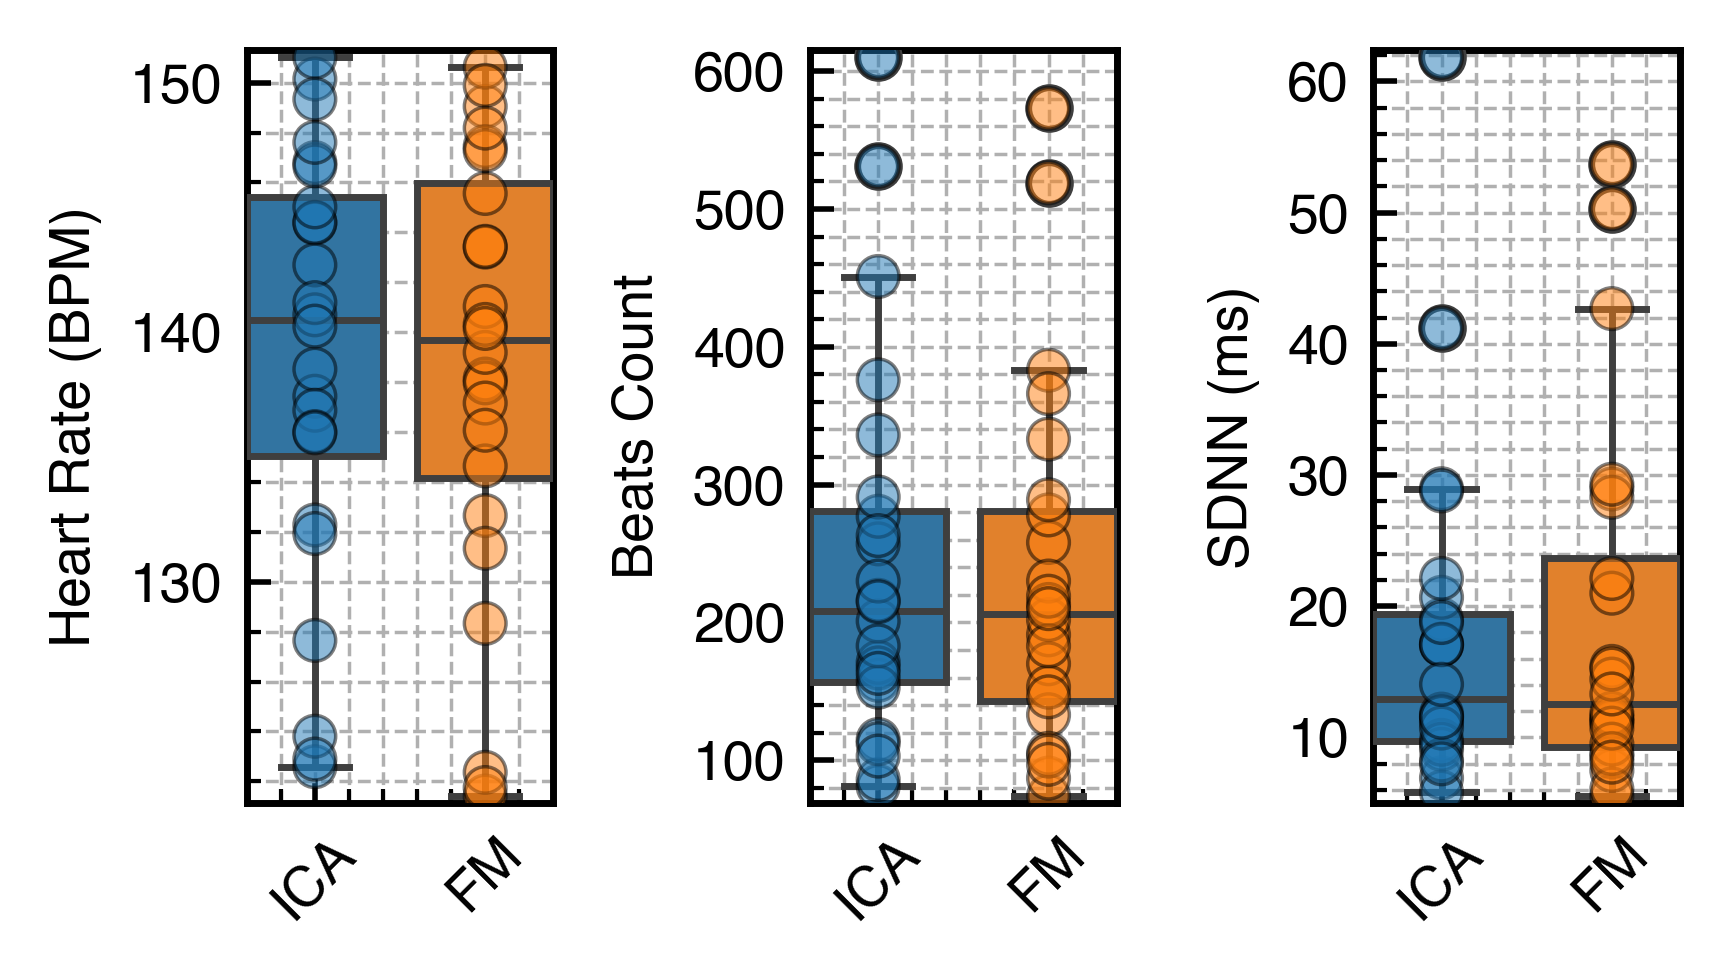

Heart Rate (BPM):
  ICS: 139.00 ± 8.59 (n=24)
  FM:  138.64 ± 8.83 (n=24)

Beats Count:
  ICS: 239.42 ± 137.49 (n=24)
  FM:  229.79 ± 129.51 (n=24)

SDNN (ms):
  ICS: 17.52 ± 12.58 (n=24)
  FM:  18.54 ± 13.72 (n=24)



In [51]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the DataFrame for visualization
melted_df = df_combined.melt(
	id_vars=['patient', 'series', 'signal_group'], 
	value_vars=['selected_beats_fetal_ics', 'selected_beats_fetal_fw', 'sdnn_fetal_ics', 'sdnn_fetal_fw', "selected_hr_fetal_ics", "selected_hr_fetal_fw", "value_ics", "value_fw"], 
	var_name='variable', 
	value_name='value_compare'
)

# Create subplots for each metric
metrics = ['selected_hr_fetal', 'selected_beats_fetal', 'sdnn_fetal']
labels = ['Heart Rate (BPM)', 'Beats Count', 'SDNN (ms)']
fig, axes = plt.subplots(1, len(metrics), figsize=(3.5, 2))

for i, metric in enumerate(metrics):
    # Filter the melted DataFrame for the current metric
    metric_df = melted_df[melted_df['variable'].str.contains(metric)]
    
    # Plot the boxplot for the current metric
    sns.boxplot(data=metric_df, x='variable', y='value_compare', hue=metric_df['variable'].str.contains('_ics').map({True: 'ICS', False: 'FW'}), ax=axes[i], legend=False, zorder=5)
    sns.scatterplot(data=metric_df, x='variable', y='value_compare', hue=metric_df['variable'].str.contains('_ics').map({True: 'ICS', False: 'FW'}), ax=axes[i], legend=False, alpha=0.5, color='gray', edgecolor='k', linewidth=0.5, zorder=9)
    #axes[i].set_title(f'{metric}')
    axes[i].set_ylabel(labels[i])
    axes[i].set_xticklabels(['ICA', 'FM'], rotation=45)
    axes[i].set_xlabel('')
    # minor ticks
    axes[i].minorticks_on()
    axes[i].grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)

plt.tight_layout()
#plt.savefig("ics_vs_fm_comparison_boxplots.pdf", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

# mean +- std
for metric, label in zip(metrics, labels):
    metric_df = melted_df[melted_df['variable'].str.contains(metric)]
    ics_values = metric_df[metric_df['variable'].str.contains('_ics')]['value_compare']
    fw_values = metric_df[metric_df['variable'].str.contains('_fw')]['value_compare']
    print(f"{label}:")
    print(f"  ICS: {ics_values.mean():.2f} ± {ics_values.std():.2f} (n={len(ics_values)})")
    print(f"  FM:  {fw_values.mean():.2f} ± {fw_values.std():.2f} (n={len(fw_values)})")
    print()

In [13]:
# cell 1: setup + data loading
import ast
import pandas as pd
import numpy as np

def get_min_from_list_str(list_str, fs=500):
    if pd.isna(list_str):
        return np.nan
    try:
        values_list = ast.literal_eval(list_str)
        finite_values = [v for v in values_list if not np.isinf(v)]
        return np.min(finite_values) / fs if finite_values else np.nan
    except:
        return np.nan

def snr(data):
    if 'heartbeats_dict' not in data:
        return np.nan
    if 'fetal' not in data['heartbeats_dict'] or 'M_x' not in data['heartbeats_dict']['fetal']:
        return np.nan
    if data['heartbeats_dict']['fetal']['M_x']['selected_peaks_mask'].sum() < 50:
        return np.nan

    mean_magnitude = np.array([data['heartbeats_dict']['fetal'][ax]['mean_beat'].values for ax in ['M_x', 'M_y', 'M_z']])
    var_magnitude = np.array([data['heartbeats_dict']['fetal'][ax]['std_beat'].values for ax in ['M_x', 'M_y', 'M_z']]) **2
    v = (np.sqrt(var_magnitude.mean(axis=0)) / np.sqrt(np.mean(np.square(mean_magnitude), axis=0))).mean()
    #v =  np.sqrt(var_magnitude.mean()) / np.linalg.norm(mean_magnitude, axis=0).max()
    #v = np.sqrt(var_magnitude.mean()) / np.sqrt(np.square(mean_magnitude).mean())

    ##v = (np.sqrt(var_magnitude) / np.abs(mean_magnitude)).mean()
    #v = np.sqrt(var_magnitude.mean()) / np.max(np.abs(mean_magnitude), axis=0).max()

    # idx = np.argmax(np.square(mean_magnitude).mean(axis=1), axis=0)
    # v = np.sqrt(var_magnitude[idx]).mean() / np.max(np.abs(mean_magnitude[idx]))

    return v


# --- load ICS dataframe ---
df = pd.DataFrame(
    values,
    columns=['patient', 'series', 'signal_group', 'value',
             'selected_hr_fetal', 'sdnn_fetal', 'RMSSD',
             'selected_beats_fetal']
)
df.set_index(['patient', 'series', 'signal_group'], inplace=True)

# --- load multiple FW trials ---
trials = {
    "FM + Correlation Penalty": "2025-09-03_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentV2_fixcopy_outlierV3_500it_1-40hz_newcorr50_win5000_5e-1",
    "FM": "2025-07-30_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentLMSv2_fixcopy_v2"
    # add more if needed
}

all_trials = []
for name, trial in trials.items():
    fw = pd.read_csv(os.path.join("/jonas/fMCG/", trial+".csv"))[[
        "patient", "series", "signal_group",
        "sdnn_fetal", "center_hr_fetal",
        "selected_hr_fetal", "selected_beats_fetal",
        "gestation", "hr_success", "noise_group"
    ]]
    fw = fw.dropna(subset=['noise_group'])
    if name == "FM":
        fw = fw[~((fw.patient == "P096") & (fw.series == "S01") & (fw.signal_group == "R001"))]

    dir = "/jonas/fMCG/output"
    records = sorted(glob.glob(os.path.join(dir, trial, "*/*.pkl")))
    values_fw = np.array([snr(np.load(record, allow_pickle=True)) for record in records])
    fw['value'] = values_fw  # assumes values_fw matches per trial

    fw = fw[fw.hr_success == "success"]
    fw['sdnn_fetal'] = fw['sdnn_fetal'].apply(get_min_from_list_str)
    fw['GA'] = fw['gestation'].str[1:].astype(float)
    fw['trial'] = name
    fw.set_index(['patient', 'series', 'signal_group'], inplace=True)

    # --- join ICS with this FW trial to inherit GA ---
    joined = df.join(fw, how='inner', lsuffix='_ics').reset_index()

    # melt into long form
    melted = joined.melt(
        id_vars=['patient', 'series', 'signal_group', 'GA', 'trial'],
        value_vars=[
            'selected_beats_fetal_ics', 'sdnn_fetal_ics', 'selected_hr_fetal_ics', 'value_ics',
            'selected_beats_fetal', 'sdnn_fetal', 'selected_hr_fetal', 'value'
        ],
        var_name='variable',
        value_name='value_compare'
    )

    # clean up metric + trial labels
    melted['metric'] = melted['variable'].str.replace('_ics', '').str.replace('_fw', '')
    melted['trial'] = np.where(melted['variable'].str.endswith('_ics'), 'ICS', melted['trial'])

    all_trials.append(melted)

# final combined dataset with ICS + all FW trials
melted_df = pd.concat(all_trials, ignore_index=True)


/tmp/ipykernel_245661/545283244.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_245661/545283244.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_245661/545283244.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_245661/545283244.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


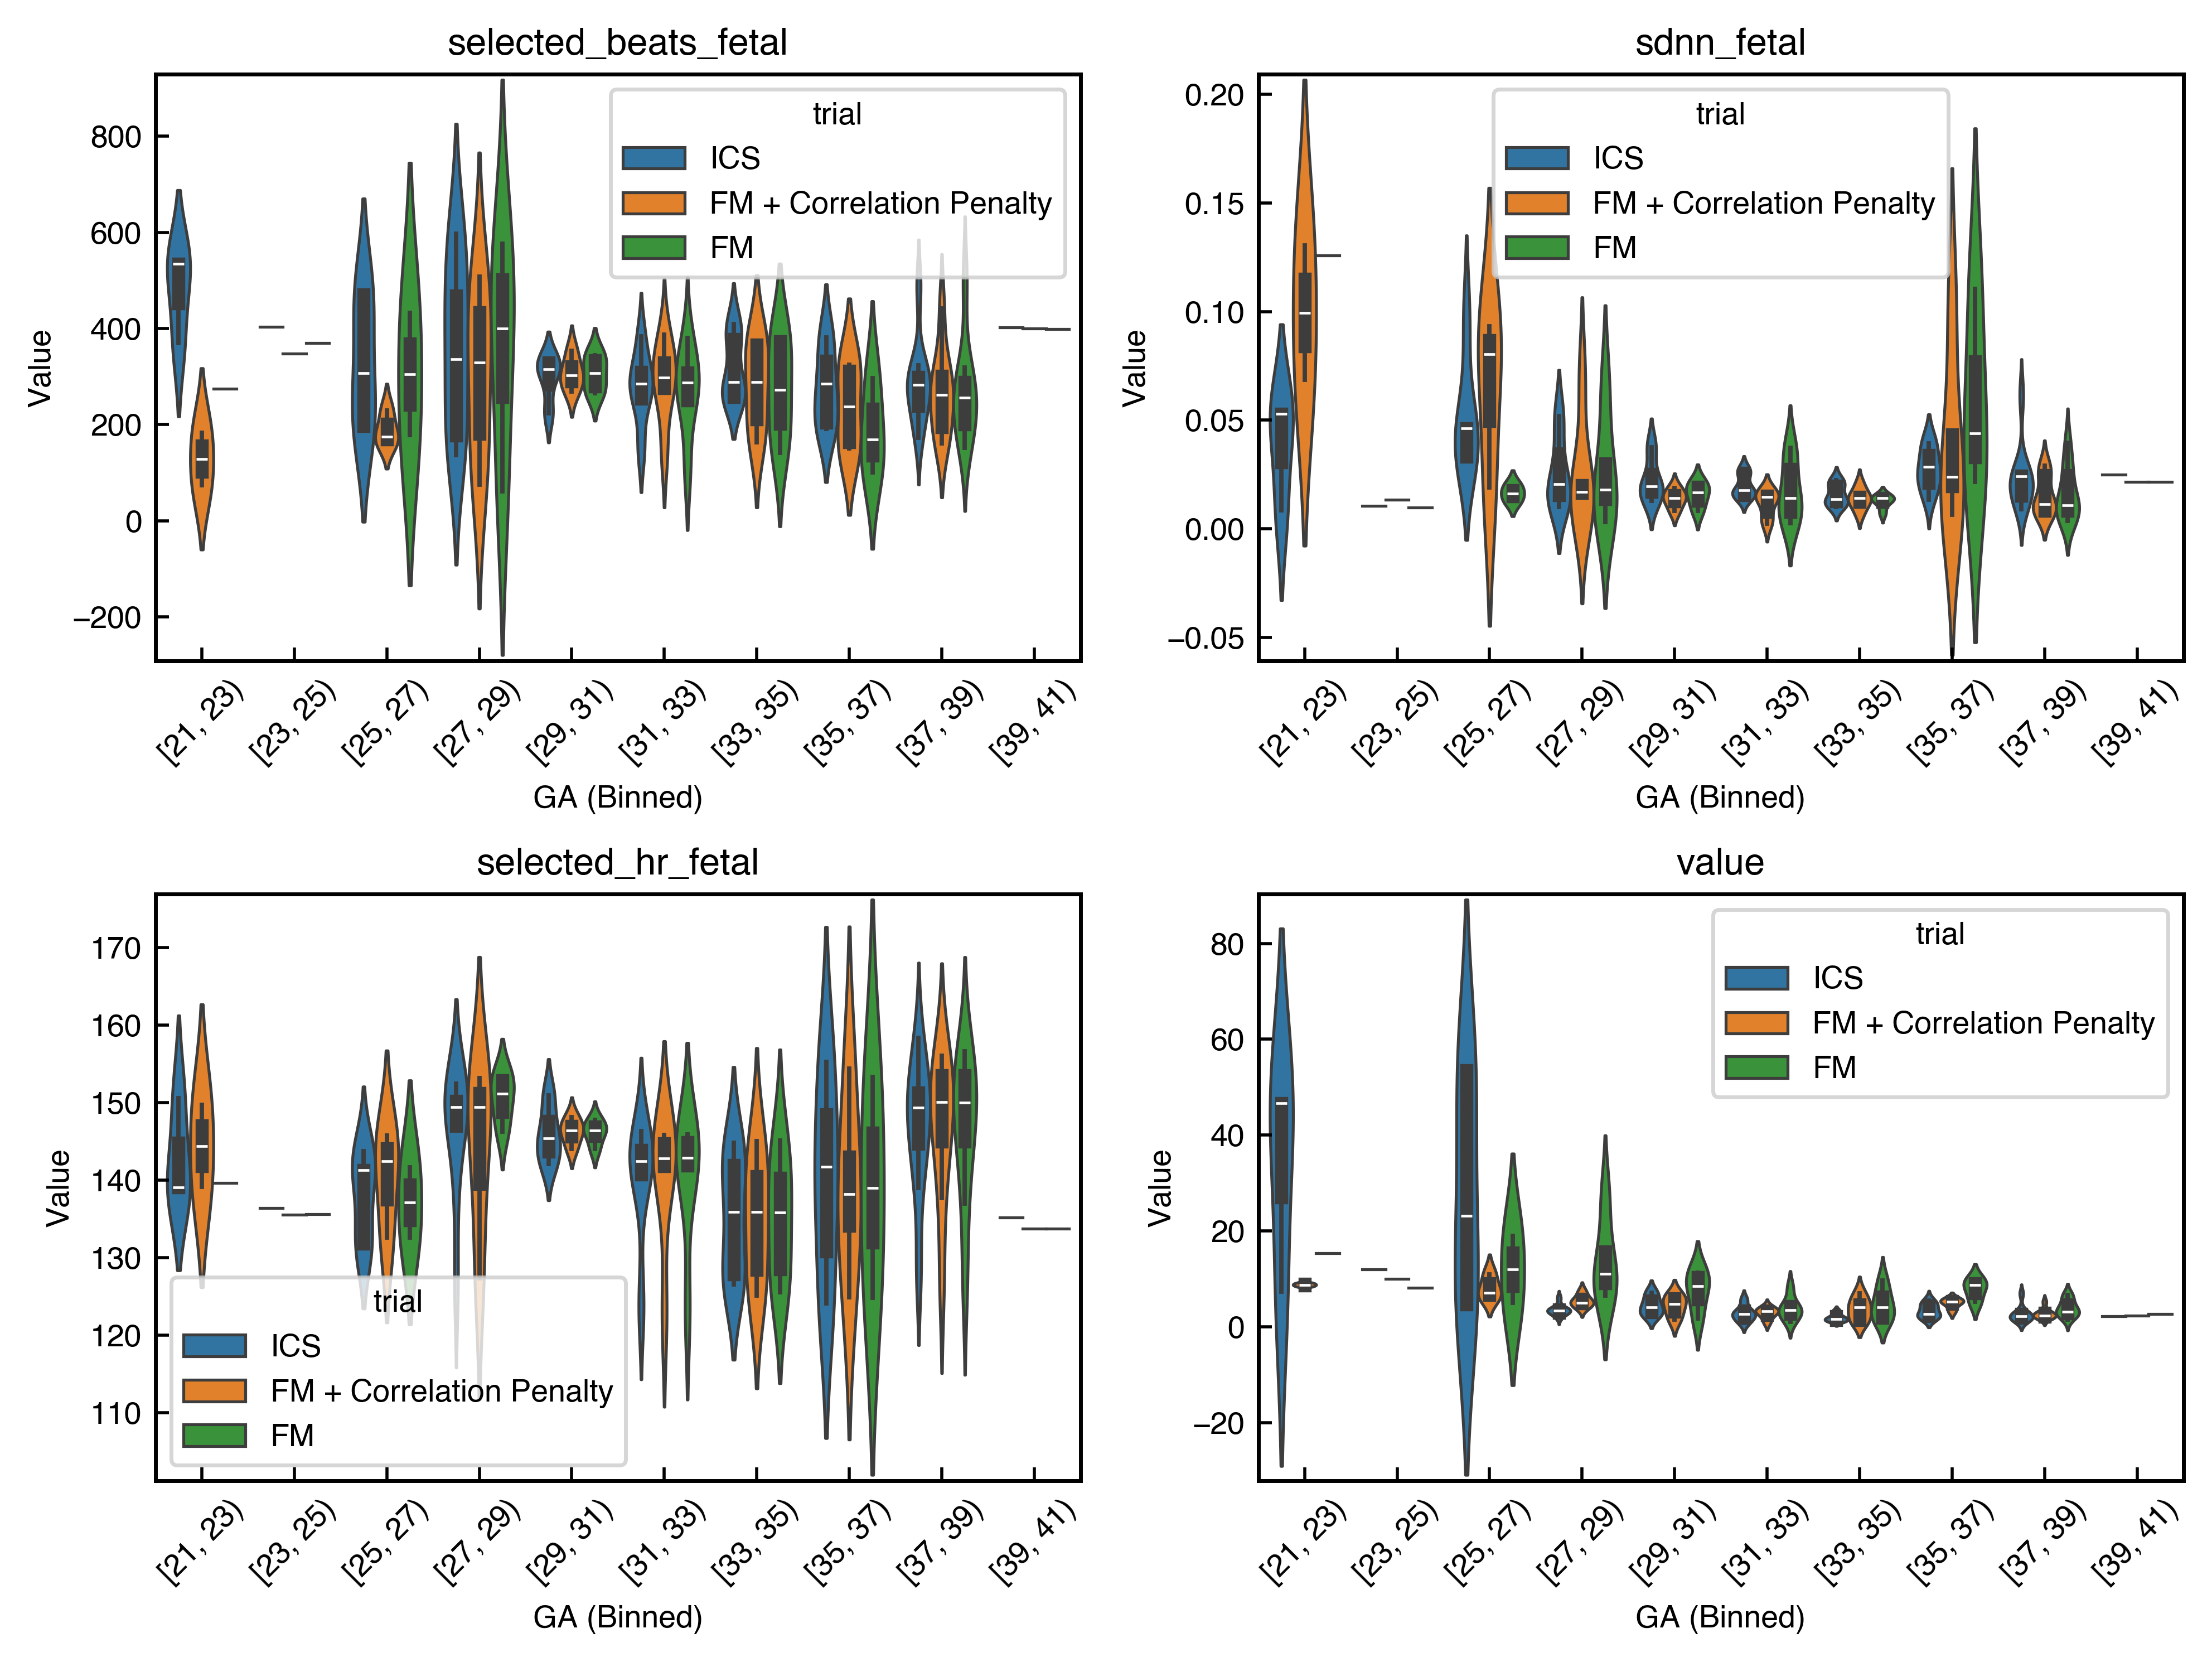

In [14]:
# cell 2: GA-binned violin plots
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

# bin GA for FW trials (ICS has NaN GA)
melted_df['GA_binned'] = pd.cut(
    melted_df['GA'].dropna(),
    bins=range(int(melted_df['GA'].min()), int(melted_df['GA'].max()) + 2, 2),
    right=False
)

metrics = melted_df['metric'].unique()
fig, axes = plt.subplots(len(metrics)//2, 2, figsize=(8, 6))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    metric_df = melted_df[melted_df['metric'] == metric]
    sns.violinplot(
        data=metric_df,
        x='GA_binned',
        y='value_compare',
        hue='trial',
        ax=axes[i],
        inner='box',
        width=0.75,
        linewidth=0.75,
        dodge=True,
        scale='width'
    )
    axes[i].set_title(metric)
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('GA (Binned)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


/tmp/ipykernel_3595981/2803349205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3595981/2803349205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


/tmp/ipykernel_3595981/2803349205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_3595981/2803349205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


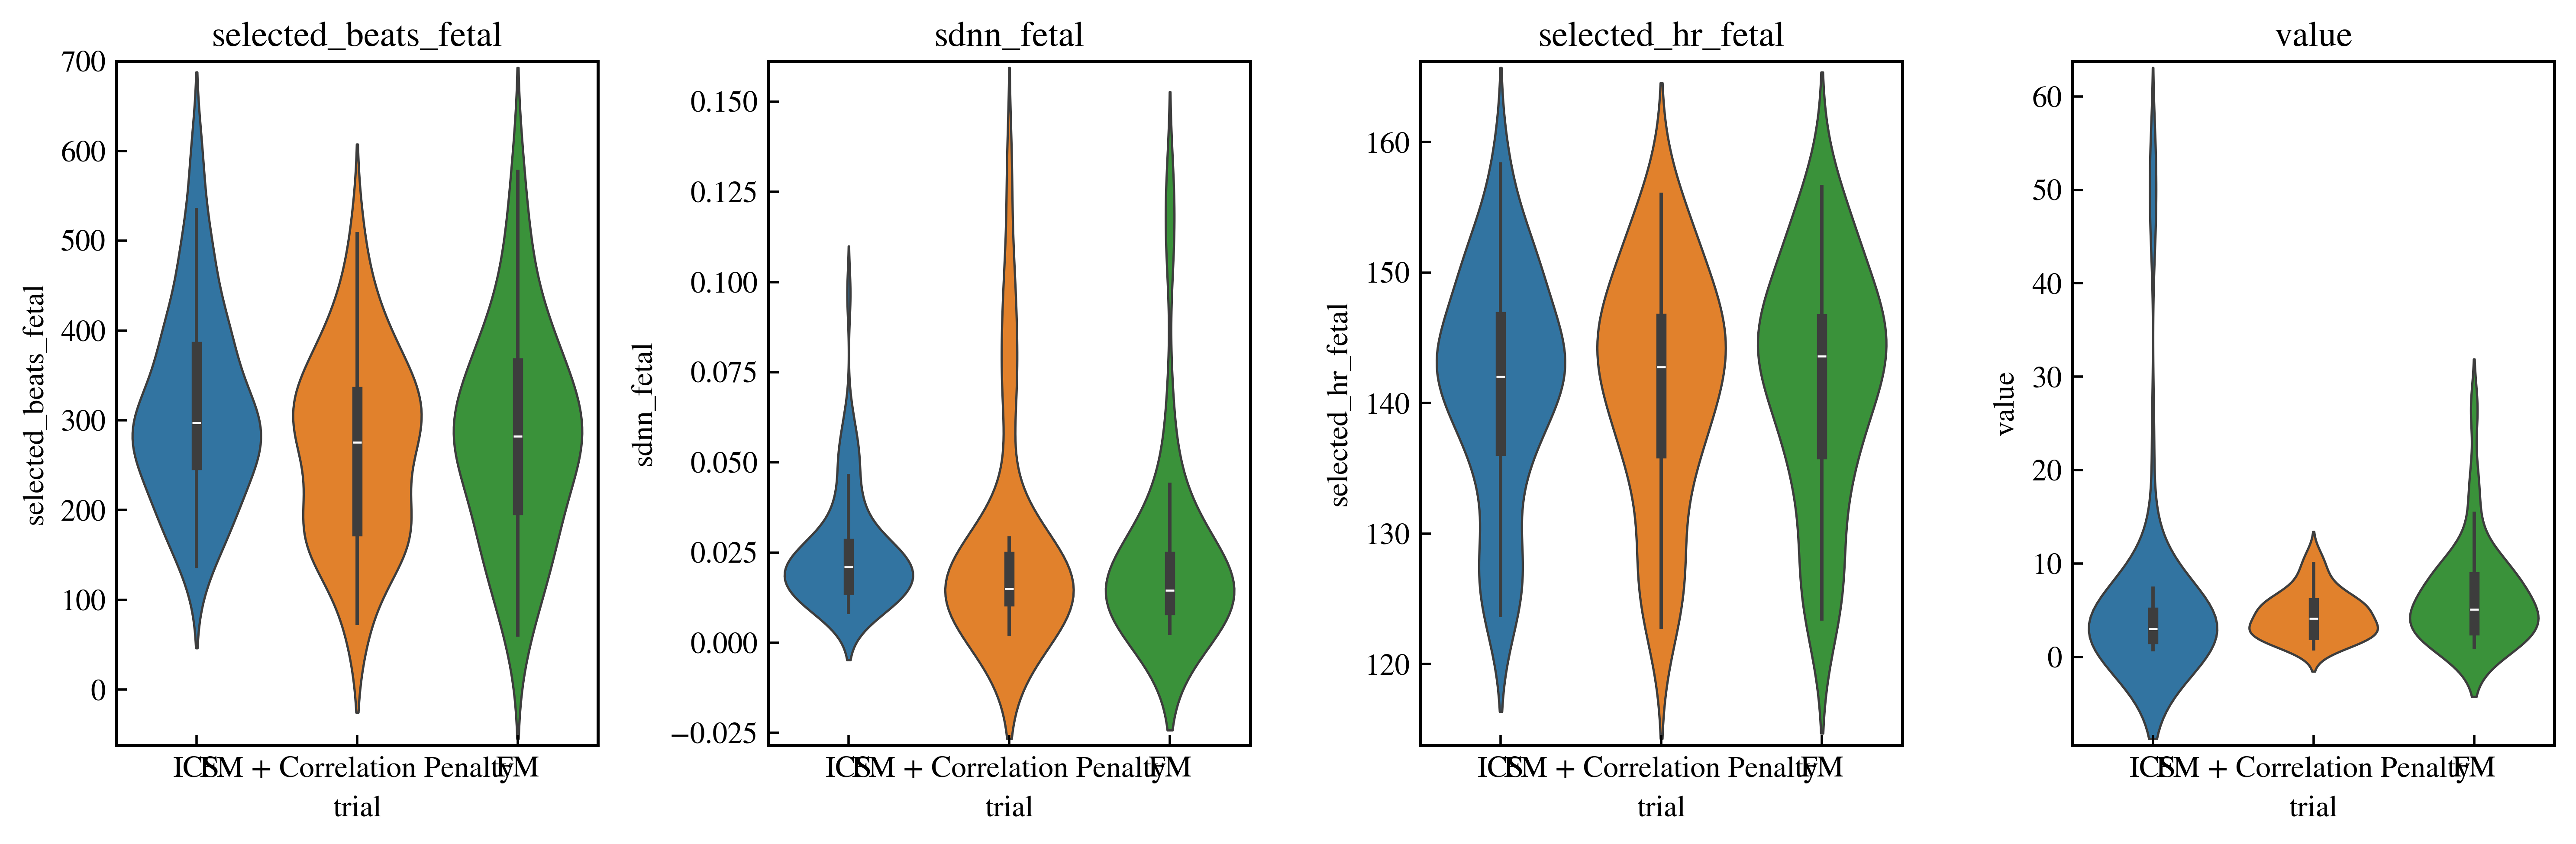

In [ ]:
# cell 3: trial-level comparison (ICS vs FW1 vs FW2...)
fig, axes = plt.subplots(1, len(metrics), figsize=(12, 4))

for i, metric in enumerate(metrics):
    metric_df = melted_df[melted_df['metric'] == metric]
    sns.violinplot(
        data=metric_df,
        x='trial',
        y='value_compare',
        ax=axes[i],
        inner='box',
        linewidth=0.75, 
        palette=['tab:blue', 'tab:orange', 'tab:green'],
    )
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    #axes[i].set_xlabel('Trial')


plt.tight_layout()
plt.show()


In [19]:
metric_df

,patient,series,signal_group,GA,trial,variable,value_compare,metric,GA_binned
120,P048,S02,R001,31.0,ICS,value_ics,2.272033,value,"[31, 33)"
121,P051,S02,R001,31.0,ICS,value_ics,1.814770,value,"[31, 33)"
122,P054,S04,R001,22.0,ICS,value_ics,7.372905,value,"[21, 23)"
123,P054,S07,R001,26.0,ICS,value_ics,23.201206,value,"[25, 27)"
124,P054,S08,R002,28.0,ICS,value_ics,3.360284,value,"[27, 29)"
...,...,...,...,...,...,...,...,...,...
603,P097,S01,R003,21.0,FM,value,15.370986,value,"[21, 23)"
604,P097,S02,R001,23.0,FM,value,8.119193,value,"[23, 25)"
605,P097,S03,R001,26.0,FM,value,4.980393,value,"[25, 27)"
606,P071,S01,R001,38.0,FM,value,4.443957,value,"[37, 39)"


In [25]:
melted_df.groupby(['trial', 'metric', "GA_binned"])['value_compare'].agg(['mean', 'std']).unstack(0)

/tmp/ipykernel_245661/222828609.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  melted_df.groupby(['trial', 'metric', "GA_binned"])['value_compare'].agg(['mean', 'std']).unstack(0)


mean                           \
trial                                   FM FM + Correlation Penalty   
metric               GA_binned                                        
sdnn_fetal           [21, 23)     0.125862                 0.099446   
                     [23, 25)     0.009684                 0.013342   
                     [25, 27)     0.016319                 0.064187   
                     [27, 29)     0.025569                 0.025177   
                     [29, 31)     0.015609                 0.013848   
                     [31, 33)     0.017612                 0.011491   
                     [33, 35)     0.012546                 0.013721   
                     [35, 37)     0.058650                 0.038898   
                     [37, 39)     0.016327                 0.015468   
                     [39, 41)     0.021523                 0.021521   
selected_beats_fetal [21, 23)   275.000000               128.500000   
                     [23, 25)   370.000000               348.000000   
                     [25, 27)   305.000000               189.333333   
                     [27, 29)   359.500000               305.400000   
                     [29, 31)   306.000000               307.000000   
                     [31, 33)   269.500000               289.000000   
                     [33, 35)   273.800000               280.800000   
                     [35, 37)   189.000000               237.500000   
                     [37, 39)   266.666667               265.222222   
                     [39, 41)   399.000000               400.000000   
selected_hr_fetal    [21, 23)   139.600000               144.390000   
                     [23, 25)   135.610000               135.540000   
                     [25, 27)   137.095000               140.223333   
                     [27, 29)   150.425000               144.078000   
                     [29, 31)   146.110000               146.205000   
                     [31, 33)   140.346667               140.163333   
                     [33, 35)   135.018000               134.960000   
                     [35, 37)   139.016667               138.880000   
                     [37, 39)   146.463333               146.492222   
                     [39, 41)   133.740000               133.740000   
value                [21, 23)    15.370986                 8.774438   
                     [23, 25)     8.119193                10.002910   
                     [25, 27)    11.960623                 8.108577   
                     [27, 29)    13.787536                 5.385029   
                     [29, 31)     7.519116                 4.323461   
                     [31, 33)     3.870964                 2.814869   
                     [33, 35)     4.678479                 3.685053   
                     [35, 37)     7.764193                 4.860060   
                     [37, 39)     3.895804                 2.705399   
                     [39, 41)     2.685175                 2.323757   

                                                   std  \
trial                                  ICS          FM   
metric               GA_binned                           
sdnn_fetal           [21, 23)     0.038037         NaN   
                     [23, 25)     0.010638         NaN   
                     [25, 27)     0.051100    0.004309   
                     [27, 29)     0.025617    0.026112   
                     [29, 31)     0.022423    0.005657   
                     [31, 33)     0.019610    0.014019   
                     [33, 35)     0.015640    0.003083   
                     [35, 37)     0.027360    0.046092   
                     [37, 39)     0.023875    0.012116   
                     [39, 41)     0.025056         NaN   
selected_beats_fetal [21, 23)   480.000000         NaN   
                     [23, 25)   403.000000         NaN   
                     [25, 27)   328.600000  179.605122   
                     [27, 29)   365.222222  224.756906  

In [ ]:
import glob
dir = "/jonas/fMCG/output"
trial = "2025-09-03_true_true_remove_artifacts_early_stop_lrgroups_lamb_1e0_haar_coeffdepthNone_1s_3sig_whitenPCA_subsequentV2_fixcopy_outlierV3_500it_1-40hz_newcorr50_win5000_5e-1"
records = sorted(glob.glob(os.path.join(dir, trial, "*/*.pkl")))


np.load(records[0], allow_pickle=True)['heartbeats_dict']['fetal']

{'data_dict': {'fetal': {'dipole_moments': array([[nan, nan, nan],
          [nan, nan, nan],
          [nan, nan, nan],
          ...,
          [nan, nan, nan],
          [nan, nan, nan],
          [nan, nan, nan]]),
   'components': array([nan, nan, nan, ..., nan, nan, nan]),
   'peaks': array([  7048,   7281,   7511,   7741,   7969,   8208,   8439,   8670,
            8899,   9143,   9379,   9615,   9855,  10093,  10327,  10567,
           10800,  11031,  11262,  11491,  11719,  11944,  12174,  12401,
           12627,  12857,  13088,  13324,  13574,  13816,  14058,  14298,
           14538,  14779,  15017,  15256,  15491,  15725,  15965,  16201,
           16433,  16668,  16902,  17135,  17367,  17598,  17830,  18065,
           18305,  18570,  18820,  19068,  19312,  19554,  19793,  20033,
           20272,  20516,  20755,  20991,  21239,  21480,  21719,  21958,
           22194,  22434,  22680,  22919,  23158,  23395,  23634,  23876,
           24116,  24356,  24594,  24831,  25